# Table Of Content

| Index | Label | Title |
| --- | --- | --- |
| 1. | [Part-A](##A.1-What-is-a-discrete-dynamical-system?) | Discrete Chaotic Systems |
| 1.1 | [Part-A (plots 1)](###A.3.1-Plots-(Time-Series-&-Attractor-plots)) | Time-Series & Attractor plots |
| 1.2 | [Part-A (plots 2)](##-A.4-Bifurcation-Diagrams) | Bifurcation Diagrams |
| 2. | [Part-B](###1.-The-Core-RK4-Integrator) | Continuous Chaotic Systems |
| 2.1 | [Part-B (plots)](###4.1-Executing-Plots) | Phase-Space & Time-Series |
| 3. | [Part-C](##C.1-Parameter-sweep-of-the-Lorenz-system) | Sensitivity Analysis |
| 3.1 | [Part-C.1](##C.1-Parameter-sweep-of-the-Lorenz-system) | Lorenz system Parameter sweep |
| 3.2 | [Part-C.2](##C.2-Step-size-sensitivity) | Step-size sensitivity |


# Part A — Discrete Chaotic Systems

## A.1 What is a discrete dynamical system?
A discrete system evolves in steps rather than continuously: the state at iteration n+1 is obtained by applying a fixed map to the state at iteration n.
- `State variables`: the quantities that describe the system at a given iteration.
- `Control parameter`: a fixed constant in the chaos modeling equation that is not part of the state but controls the qualitative behaviour of the system (fixed point, periodic, or chaotic). Changing it can push the system through a cascade of bifurcations.

## A.2 Logistic Map Time-Series

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [60]:
def generate_logistic(r, x0, total_iters, transient_drop):
    # Pre-allocate the state array
    x = np.zeros(total_iters)
    x[0] = x0
    
    # Iterate the discrete map
    for n in range(total_iters - 1):
        x[n+1] = r * x[n] * (1 - x[n])
        
    # Discard the transient phase and return the asymptotic behavior
    return x[transient_drop:]

# Settings
r_logistic = 3.9
x0_logistic = 0.5
iters_logistic = 1000
drop_logistic = 450

x_log_final = generate_logistic(r_logistic, x0_logistic, iters_logistic, drop_logistic)

## A.3 Hénon Map Attractor

In [61]:
def generate_henon(a, b, x0, y0, total_iters, transient_drop):
    x = np.zeros(total_iters)
    y = np.zeros(total_iters)
    x[0], y[0] = x0, y0
    
    for n in range(total_iters - 1):
        x[n+1] = 1 - a * x[n]**2 + y[n]
        y[n+1] = b * x[n]
        
    return x[transient_drop:], y[transient_drop:]

# Settings
a_henon, b_henon = 1.4, 0.3
x0_henon, y0_henon = 0.0, 0.0
iters_henon = 5000
drop_henon = 500

x_henon_final, y_henon_final = generate_henon(a_henon, b_henon, x0_henon, y0_henon, iters_henon, drop_henon)

### A.3.1 Plots (Time-Series & Attractor plots)

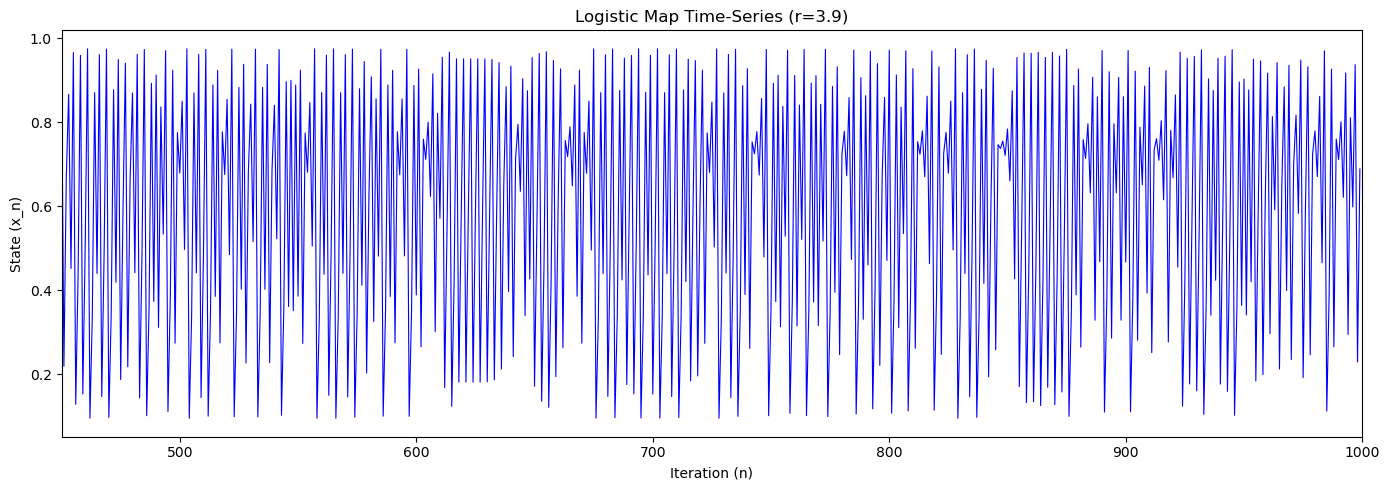

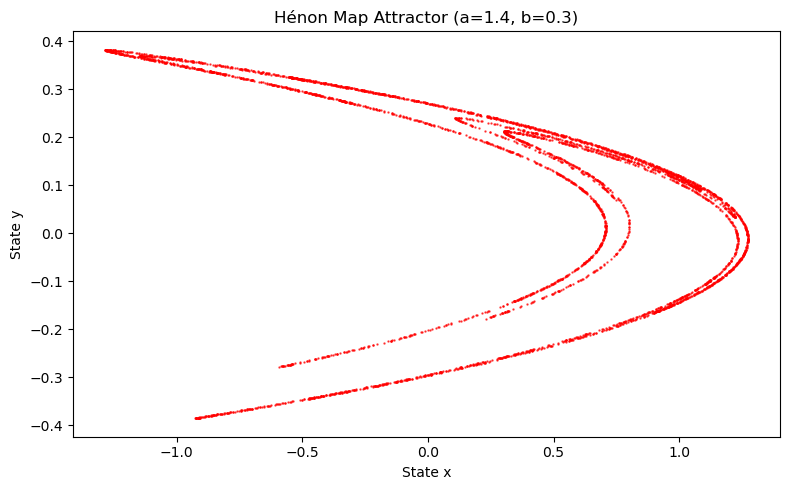

In [62]:
# Plot 1: Logistic Time-Series plot
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(range(drop_logistic, iters_logistic), x_log_final, lw=0.8, color='blue')
ax1.set_title(f"Logistic Map Time-Series (r={r_logistic})")
ax1.set_xlabel("Iteration (n)")
ax1.set_ylabel("State (x_n)")
ax1.set_xlim(450, 1000)   # the bounds adjusted according to the limit (it should be changes if we changed the limit)


plt.tight_layout()
plt.show()


# Plot 2: Hénon Attractor plot
fig, ax2 = plt.subplots(figsize=(8, 5))

ax2.scatter(x_henon_final, y_henon_final, s=0.5, color='red', alpha=0.7)
ax2.set_title(f"Hénon Map Attractor (a={a_henon}, b={b_henon})")
ax2.set_xlabel("State x")
ax2.set_ylabel("State y")

plt.tight_layout()
plt.show()

### a more tight layout

In [50]:
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# # Plot 1: Logistic Time-Series
# ax1.plot(range(drop_logistic, iters_logistic), x_log_final, lw=0.8, color='blue')
# ax1.set_title(f"Logistic Map Time-Series (r={r_logistic})")
# ax1.set_xlabel("Iteration (n)")
# ax1.set_ylabel("State (x_n)")
# # ax1.set_ylim(-0.1, 1.09)
# ax1.set_xlim(450, 1000)

# # Plot 2: Hénon Attractor
# ax2.scatter(x_henon_final, y_henon_final, s=0.5, color='red', alpha=0.7)
# ax2.set_title(f"Hénon Map Attractor (a={a_henon}, b={b_henon})")
# ax2.set_xlabel("State x")
# ax2.set_ylabel("State y")

# plt.tight_layout()
# plt.show()

## A.4 Bifurcation Diagrams

In [64]:
def plot_logistic_bifurcation():
    r_values = np.arange(2.5, 4.0, 0.005)
    total_iters = 1000
    drop = 500
    
    plt.figure(figsize=(10, 6))
    
    for r in r_values:
        # We can reuse our function from above
        x_final = generate_logistic(r, 0.5, total_iters, drop)
        # Plot x_final against the current r value
        plt.plot([r] * len(x_final), x_final, ',k', alpha=0.1)
        
    plt.title("Logistic Map Bifurcation Diagram")
    plt.xlabel("Control Parameter (r)")
    plt.ylabel("Asymptotic States (x)")
    plt.show()

def plot_henon_bifurcation():
    a_values = np.arange(1.0, 1.4, 0.002)
    b = 0.3
    total_iters = 1000
    drop = 500
    
    plt.figure(figsize=(10, 6))
    
    for a in a_values:
        # For the bifurcation, we only plot the x variable against 'a'
        x_final, _ = generate_henon(a, b, 0.0, 0.0, total_iters, drop)
        plt.plot([a] * len(x_final), x_final, ',k', alpha=0.8)
        
    plt.title("Hénon Map Bifurcation Diagram (b=0.3)")
    plt.xlabel("Control Parameter (a)")
    plt.ylabel("Asymptotic States (x)")
    plt.show()

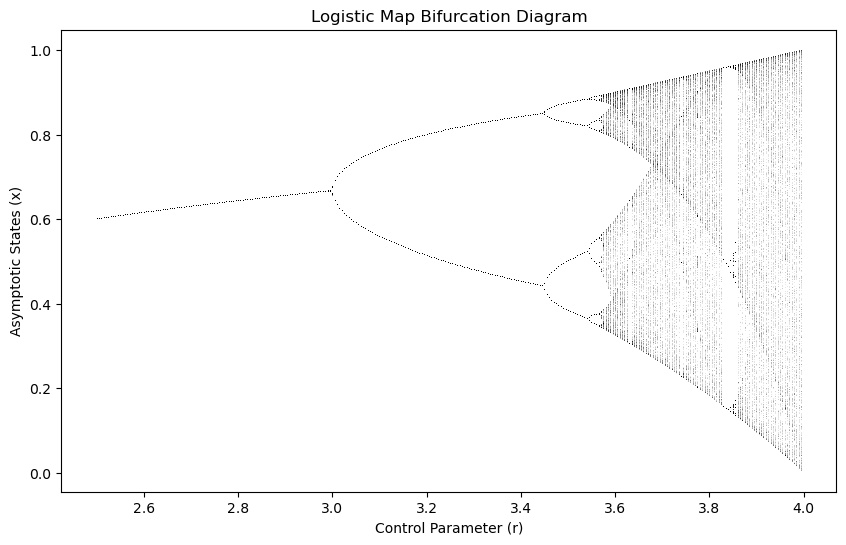

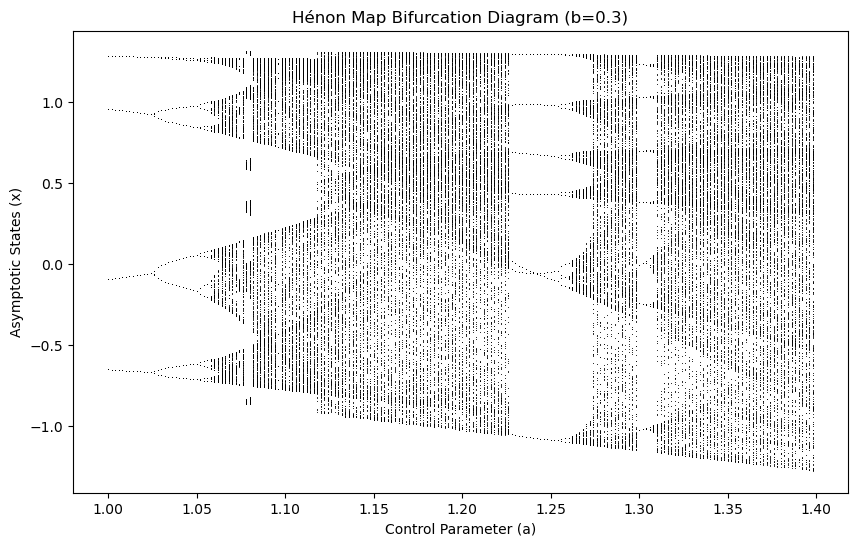

In [65]:
plot_logistic_bifurcation()
plot_henon_bifurcation()

---

# Part B — Continuous Chaotic Systems

## 1. The Core RK4 Integrator

In [13]:
def rk4_step(derivs, state, t, dt, params):
    """Calculates one RK4 step."""
    k1 = dt * derivs(t, state, *params)
    k2 = dt * derivs(t + dt/2, state + k1/2, *params)
    k3 = dt * derivs(t + dt/2, state + k2/2, *params)
    k4 = dt * derivs(t + dt, state + k3, *params)
    return state + (k1 + 2*k2 + 2*k3 + k4) / 6.0

def simulate_flow(derivs, initial_condition, T, dt, params):
    """Runs the simulation over time T."""
    steps = int(T / dt)
    states = np.zeros((steps, len(initial_condition)))
    states[0] = initial_condition
    time_vals = np.linspace(0, T, steps)
    
    for i in range(1, steps):
        states[i] = rk4_step(derivs, states[i-1], time_vals[i-1], dt, params)
        
    return time_vals, states

## 2. System Equations (Derivatives)

### B.2 Lorenz System

In [15]:
def lorenz(t, state, sigma, rho, beta):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return np.array([dx, dy, dz])

### B.3 Rössler System

In [16]:
def rossler(t, state, a, b, c):
    x, y, z = state
    dx = -y - z
    dy = x + a * y
    dz = b + z * (x - c)
    return np.array([dx, dy, dz])


### B.4 Chen System

In [17]:
def chen(t, state, a, b, c):
    x, y, z = state
    dx = a * (y - x)
    dy = (c - a) * x - x * z + c * y
    dz = x * y - b * z
    return np.array([dx, dy, dz])



### B.5 Hyperchaotic Rössler System (4D)

In [18]:
def hyper_rossler(t, state, a, b, c, d):
    x, y, z, w = state
    dx = -y - z
    dy = x + a * y + w
    dz = b + x * z
    dw = -c * z + d * w
    return np.array([dx, dy, dz, dw])

## 3. Execution & Settings

In [19]:
# Lorenz Settings
t_lor, states_lor = simulate_flow(lorenz, [1.0, 1.0, 1.0], 50, 0.01, (10, 28, 8/3))

# Rössler Settings
t_ros, states_ros = simulate_flow(rossler, [1.0, 1.0, 1.0], 250, 0.01, (0.2, 0.2, 5.7))

# Chen Settings (Stiffer system, using smaller dt)
t_chen, states_chen = simulate_flow(chen, [-0.1, 0.5, -0.6], 50, 0.005, (35, 3, 28))

# Hyperchaotic Rössler Settings
t_hyper, states_hyper = simulate_flow(hyper_rossler, [-10.0, -6.0, 0.0, 10.0], 250, 0.01, (0.25, 3.0, 0.5, 0.05))

## 4. Plotting

In [20]:
def plot_3d_system(time_vals, states, name):
    fig = plt.figure(figsize=(12, 5))
    
    # 3D Phase Space
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot(states[:, 0], states[:, 1], states[:, 2], lw=0.5, color='b')
    ax1.set_title(f'{name} Phase Space')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    
    # Time Series
    ax2 = fig.add_subplot(122)
    ax2.plot(time_vals, states[:, 0], lw=0.8, label='x(t)')
    ax2.plot(time_vals, states[:, 1], lw=0.8, label='y(t)', alpha=0.7)
    ax2.plot(time_vals, states[:, 2], lw=0.8, label='z(t)', alpha=0.7)
    ax2.set_title(f'{name} Time Series')
    ax2.set_xlabel('Time')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

### 4.1 Executing Plots

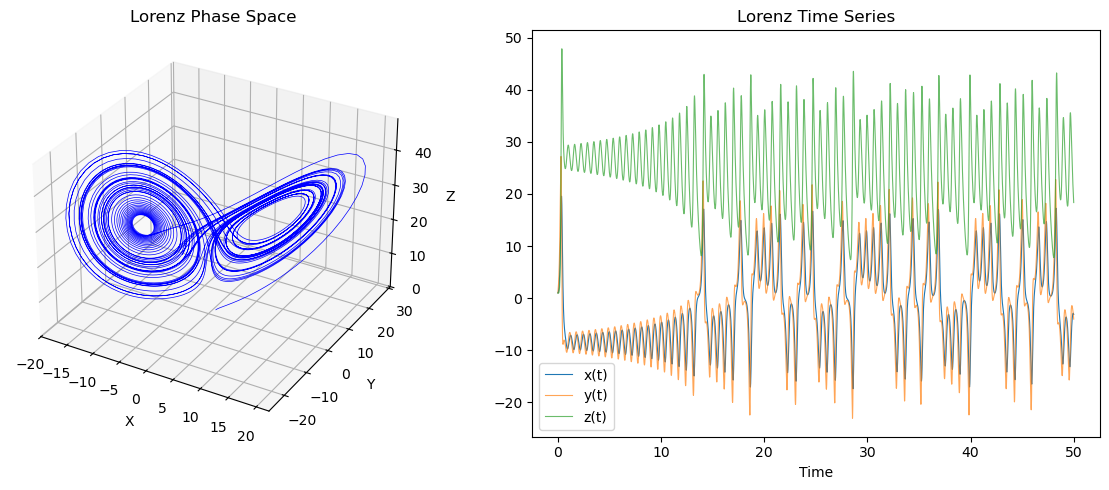

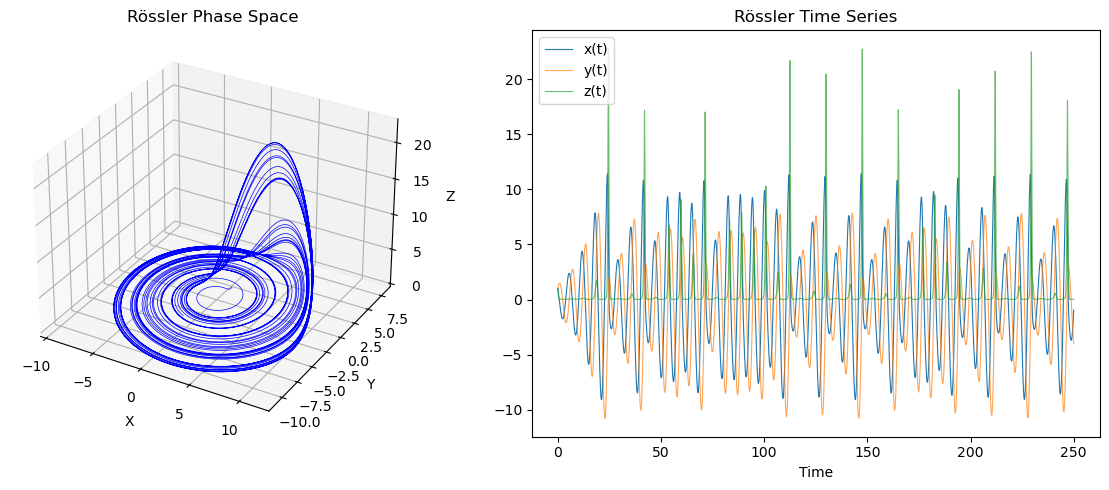

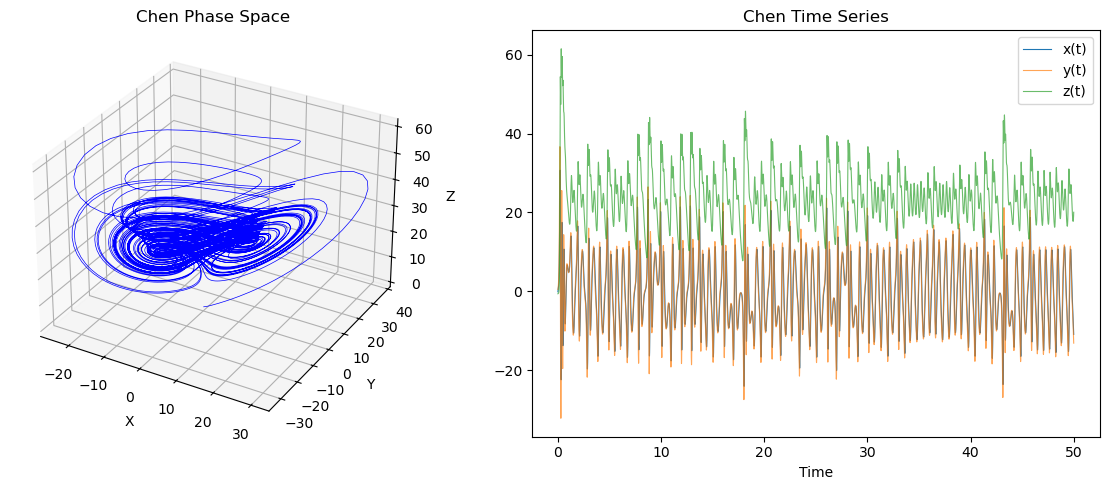

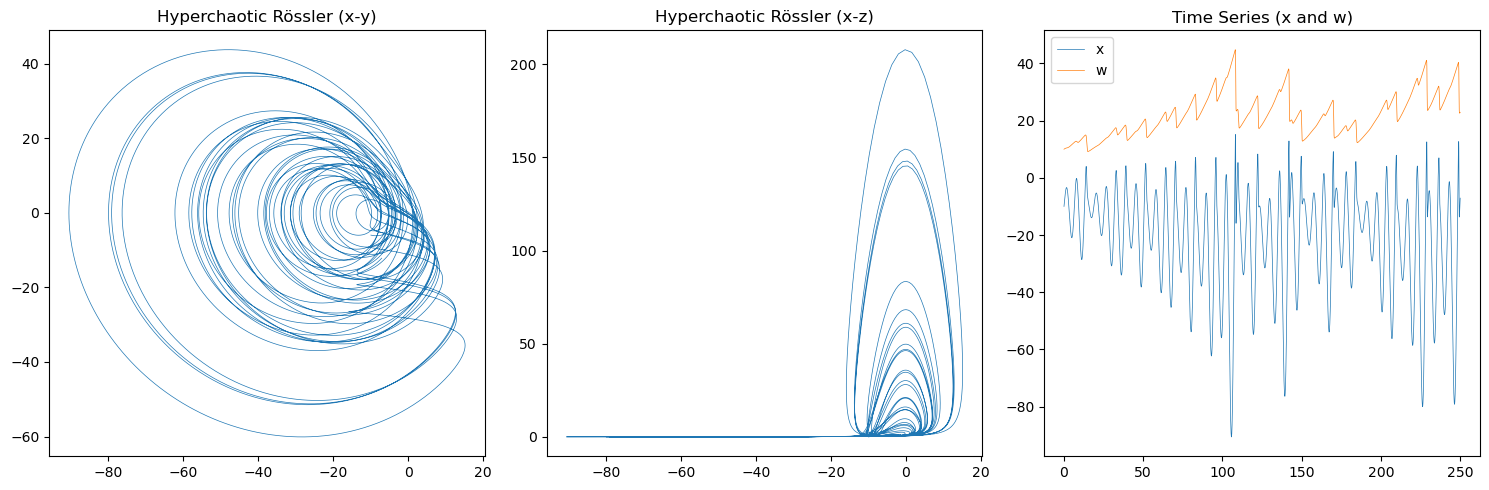

In [21]:
plot_3d_system(t_lor, states_lor, "Lorenz")
plot_3d_system(t_ros, states_ros, "Rössler")
plot_3d_system(t_chen, states_chen, "Chen")

# Generate 4D Hyperchaotic Plot (Projections)
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131)
ax1.plot(states_hyper[:, 0], states_hyper[:, 1], lw=0.5)
ax1.set_title('Hyperchaotic Rössler (x-y)')

ax2 = fig.add_subplot(132)
ax2.plot(states_hyper[:, 0], states_hyper[:, 2], lw=0.5)
ax2.set_title('Hyperchaotic Rössler (x-z)')

ax3 = fig.add_subplot(133)
ax3.plot(time_vals_hyper := t_hyper, states_hyper[:, 0], lw=0.5, label='x')
ax3.plot(time_vals_hyper, states_hyper[:, 3], lw=0.5, label='w')
ax3.set_title('Time Series (x and w)')
ax3.legend()

plt.tight_layout()
plt.show()

# Part C — Sensitivity Analysis

## C.1 Parameter sweep of the Lorenz system

### C.1.1 Core Integrator and Equations

In [ ]:
def rk4_step(derivs, state, t, dt, params):
    k1 = dt * derivs(t, state, *params)
    k2 = dt * derivs(t + dt/2, state + k1/2, *params)
    k3 = dt * derivs(t + dt/2, state + k2/2, *params)
    k4 = dt * derivs(t + dt, state + k3, *params)
    return state + (k1 + 2*k2 + 2*k3 + k4) / 6.0

def lorenz(t, state, sigma, rho, beta):
    x, y, z = state
    return np.array([
        sigma * (y - x),
        x * (rho - z) - y,
        x * y - beta * z
    ])

### C.1.2 Sweep Setup & Initialization

In [24]:
sigma = 10.0
beta = 8/3

# Sweeping rho from 0 to 30 with a step of 0.25
rho_values = np.arange(0, 30.1, 0.1)  # 0.25 --> 0.1  (smaller step size)

dt = 0.01
T = 150                 # Total simulation time per rho, increase it ( 50 --> 150)
drop_time = 20         # The initial transient time to discard
drop_index = int(drop_time / dt)

# Lists to store the final coordinates for the scatter plot
rho_plot = []
z_max_plot = []

### C.1.3 The Execution Loop

In [25]:
for rho in rho_values:
    state = np.array([1.0, 1.0, 1.0])
    time_vals = np.arange(0, T, dt)
    z_history = np.zeros(len(time_vals))
    z_history[0] = state[2]
    
    # Generate the continuous wave for the current rho
    for i in range(1, len(time_vals)):
        state = rk4_step(lorenz, state, time_vals[i-1], dt, (sigma, rho, beta))
        z_history[i] = state[2]
        
    # Discard the transient phase
    z_stable = z_history[drop_index:]
    
    # Pure NumPy peak finder: a peak is greater than the point before and after it
    peaks_mask = (z_stable[1:-1] > z_stable[:-2]) & (z_stable[1:-1] > z_stable[2:])
    peaks = z_stable[1:-1][peaks_mask]
    
    # Store the peaks against the current rho value
    for peak in peaks:
        rho_plot.append(rho)
        z_max_plot.append(peak)

### C.1.4 Visualization

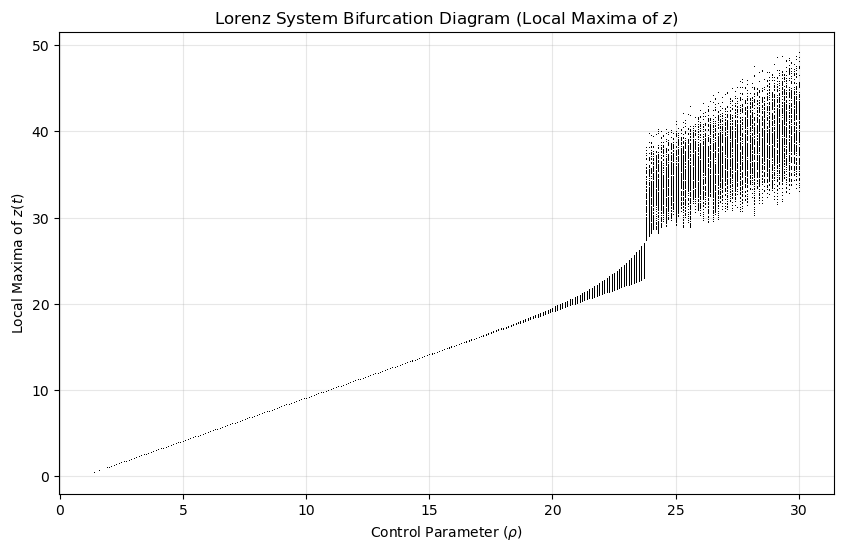

In [45]:
plt.figure(figsize=(10, 6))
plt.plot(rho_plot, z_max_plot, ',k', alpha=1)
plt.title(r"Lorenz System Bifurcation Diagram (Local Maxima of $z$)")
plt.xlabel(r"Control Parameter ($\rho$)")
plt.ylabel(r"Local Maxima of $z(t)$")
# plt.ylim(1, 26)
plt.grid(True, alpha=0.3)
plt.show()

## C.2 Step-size sensitivity

### C.2.1 RK4 Integrator and Lorenz Equations

In [ ]:
def rk4_step(derivs, state, t, dt, params):
    k1 = dt * derivs(t, state, *params)
    k2 = dt * derivs(t + dt/2, state + k1/2, *params)
    k3 = dt * derivs(t + dt/2, state + k2/2, *params)
    k4 = dt * derivs(t + dt, state + k3, *params)
    return state + (k1 + 2*k2 + 2*k3 + k4) / 6.0

def lorenz(t, state, sigma, rho, beta):
    x, y, z = state
    return np.array([
        sigma * (y - x),
        x * (rho - z) - y,
        x * y - beta * z
    ])

def simulate_lorenz(dt, T):
    params = (10.0, 28.0, 8/3) # Standard chaotic parameters
    state = np.array([1.0, 1.0, 1.0])
    steps = int(T / dt) + 1
    time_vals = np.linspace(0, T, steps)
    states = np.zeros((steps, 3))
    states[0] = state

    for i in range(1, steps):
        states[i] = rk4_step(lorenz, states[i-1], time_vals[i-1], dt, params)
    return time_vals, states

### C.2.2 Execution of the Three Step Sizes

In [55]:
T_sim = 30  # 30 time units is enough to clearly see the divergence

t_fine, states_fine = simulate_lorenz(0.001, T_sim)
t_base, states_base = simulate_lorenz(0.01, T_sim)
t_coarse, states_coarse = simulate_lorenz(0.05, T_sim)

### C.2.3 Calculating Pairwise Divergence

In [56]:
# We use np.interp to align the fine and coarse arrays to the baseline time steps
x_fine_aligned = np.interp(t_base, t_fine, states_fine[:, 0])
x_coarse_aligned = np.interp(t_base, t_coarse, states_coarse[:, 0])

div_fine = np.abs(x_fine_aligned - states_base[:, 0])
div_coarse = np.abs(x_coarse_aligned - states_base[:, 0])

### C.2.4 Visualization of the Three Deliverables

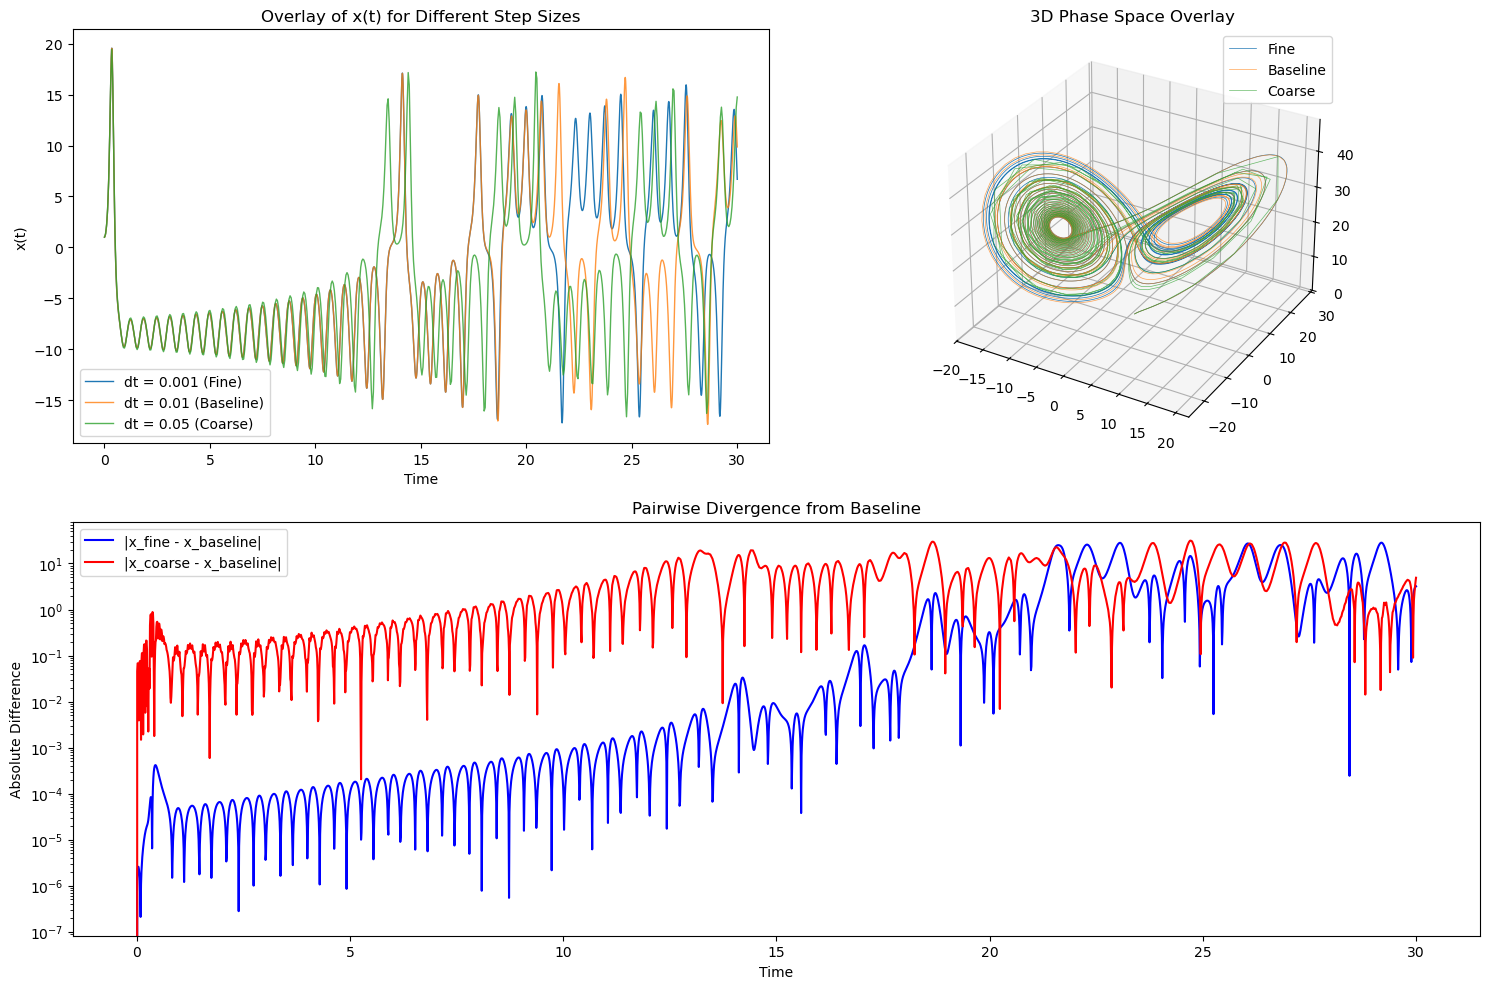

In [57]:
fig = plt.figure(figsize=(15, 10))

# Plot (i): Overlay x(t)
ax1 = fig.add_subplot(221)
ax1.plot(t_fine, states_fine[:, 0], label='dt = 0.001 (Fine)', lw=1)
ax1.plot(t_base, states_base[:, 0], label='dt = 0.01 (Baseline)', lw=1, alpha=0.8)
ax1.plot(t_coarse, states_coarse[:, 0], label='dt = 0.05 (Coarse)', lw=1, alpha=0.8)
ax1.set_title("Overlay of x(t) for Different Step Sizes")
ax1.set_xlabel("Time")
ax1.set_ylabel("x(t)")
ax1.legend()

# Plot (ii): Overlay 3D Phase Space
ax2 = fig.add_subplot(222, projection='3d')
ax2.plot(states_fine[:, 0], states_fine[:, 1], states_fine[:, 2], label='Fine', lw=0.5)
ax2.plot(states_base[:, 0], states_base[:, 1], states_base[:, 2], label='Baseline', lw=0.5, alpha=0.7)
ax2.plot(states_coarse[:, 0], states_coarse[:, 1], states_coarse[:, 2], label='Coarse', lw=0.5, alpha=0.7)
ax2.set_title("3D Phase Space Overlay")
ax2.legend()

# Plot (iii): Pairwise Divergence
ax3 = fig.add_subplot(212)
ax3.plot(t_base, div_fine, label='|x_fine - x_baseline|', color='blue')
ax3.plot(t_base, div_coarse, label='|x_coarse - x_baseline|', color='red')
ax3.set_title("Pairwise Divergence from Baseline")
ax3.set_xlabel("Time")
ax3.set_ylabel("Absolute Difference")
ax3.set_yscale('log') # Log scale helps visualize exponential divergence
ax3.legend()

plt.tight_layout()
plt.show()